GEOG5990M Final Assignment

Student ID number: 202002946

# Defining the Problem

Health inequalities refer to unequal differences in health between social groups or places, and they are one of the issues that must be addressed in urban planning. One of the main determinants of health inequalities is socioeconomic deprivation. Several studies have investigated this relationship at the national level. For example, Marmot et al. (2020) observed that life expectancy tends to be shorter in more deprived areas in England. However, it is also important to analyse this relationship at a local scale, because health inequalities are not evenly distributed within cities and because local authorities are responsible for many practical countermeasures.

This notebook investigates the association between deprivation and health inequality in Leeds, using life expectancy as a measure of health outcomes and the Index of Multiple Deprivation (IMD) as a measure of area-level deprivation. By combining and analysing these datasets, the notebook aims to provide insight into how deprivation correlates with life expectancy across neighbourhoods in Leeds, providing evidence that can support local decision-making for the public good.

# Collecting Data

This notebook examines two variables: life expectancy at birth in England (2016–2020) and the 2019 Index of Multiple Deprivation (IMD) scores.

Life expectancy at birth is used as a measure of health inequality. The dataset, provided by the Office for National Statistics (2021) in Excel format, is available at https://www.ons.gov.uk/peoplepopulationandcommunity/birthsdeathsandmarriages/lifeexpectancies/adhocs/13926lifeexpectancyatbirthandage65yearsbysexformiddlelayersuperoutputareasmsoasengland2016to2020. It provides life expectancy at the MSOA (2011) level. Although it also contains life expectancy at age 65, birth data are used as they better reflect general health inequality. Male life expectancy is in Sheet 4, and female life expectancy is in Sheet 5.

The IMD scores (2019) were obtained from mySociety (2019) and are available at https://research.mysociety.org/sites/imd2019/about/. They provide overall deprivation scores for each MSOA, calculated from domains such as income, employment, and crime. Higher scores indicate greater deprivation.

For spatial analysis, MSOA boundary data (2011) from the Office for National Statistics were used instead of the 2021 boundaries, as the other datasets are based on MSOA 2011. The GeoJSON file is available at https://geoportal.statistics.gov.uk/datasets/ons::middle-layer-super-output-areas-december-2011-boundaries-ew-bgc-v3-1/about.

Finally, a lookup dataset linking MSOA 2011 to Local Authority Districts was used to extract Leeds data. This dataset, provided by the Office for National Statistics (2025), is available at https://geoportal.statistics.gov.uk/datasets/ons::msoa-2011-to-msoa-2021-to-local-authority-district-2022-best-fit-lookup-for-ew-v2/about.

In [1]:
# read in required packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
!pip install contextily
import contextily as cx

Next, all datasets are imported. Note that the sheet number is specified when loading the life expectancy dataset, as the Excel file contains multiple sheets. Also, since the first row does not contain the column names, the second row is specified as the column labels.

In [2]:
# read life expectancy data for males and females
# set the sheet number to 3 and header = 1
life_expectancy_males = pd.read_excel('lebymsoas.xlsx', sheet_name = 3, header = 1)
# set the sheet number to 4 and header = 1
life_expectancy_females = pd.read_excel('lebymsoas.xlsx', sheet_name = 4, header = 1)

# read imd scores data
imd = pd.read_csv('imd2019_msoa_level_data.csv')

# read MSOA boundary data
msoa = gpd.read_file('MSOA_Dec_2011_Boundaries_Generalised_Clipped_BGC_EW_V3_2022_-5730664396045573288.geojson')

# read the MSOA–Local Authority District lookup data
lookup = pd.read_csv('MSOA_(2011)_to_MSOA_(2021)_to_Local_Authority_District_(2022)_Best_Fit_Lookup_for_EW_(V2).csv')

# Data Exploration

## MSOA–Local Authority District Lookup Data

First, we examine the MSOA-Local Authority District (LAD) lookup table, as it will be used to subset the other datasets and extract only MSOAs within Leeds.

In [3]:
# check the first 5 rows of the data
lookup.head()

,MSOA11CD,MSOA11NM,CHNGIND,MSOA21CD,MSOA21NM,LAD22CD,LAD22NM,LAD22NMW,ObjectId
0,E02000001,City of London 001,NaN,E02000001,City of London 001,E09000001,City of London,NaN,1
1,E02000002,Barking and Dagenham 001,NaN,E02000002,Barking and Dagenham 001,E09000002,Barking and Dagenham,NaN,2
2,E02000003,Barking and Dagenham 002,NaN,E02000003,Barking and Dagenham 002,E09000002,Barking and Dagenham,NaN,3
3,E02000004,Barking and Dagenham 003,NaN,E02000004,Barking and Dagenham 003,E09000002,Barking and Dagenham,NaN,4
4,E02000005,Barking and Dagenham 004,NaN,E02000005,Barking and Dagenham 004,E09000002,Barking and Dagenham,NaN,5


Below are the descriptions of columns of interest:


*   '**MSOA11CD**': MSOA code (2011)
*   '**MSOA11NM**': MSOA name (2011)
*   '**LAD22NM**': Local Authority District name (2022)

Note that for Leeds data, the values in the LAD22NM column contain the string "Leeds". First, the rows where the LAD22NM column contains "Leeds" are extracted.

In [4]:
# extract Leeds data
lookup_leeds = lookup.loc[lookup['LAD22NM'] == 'Leeds']

# check the first 5 rows of the data
lookup_leeds.head()

,MSOA11CD,MSOA11NM,CHNGIND,MSOA21CD,MSOA21NM,LAD22CD,LAD22NM,LAD22NMW,ObjectId
2000,E02002416,Leeds 087,NaN,E02002416,Leeds 087,E08000035,Leeds,NaN,2001
2001,E02002417,Leeds 088,NaN,E02002417,Leeds 088,E08000035,Leeds,NaN,2002
2002,E02002418,Leeds 089,NaN,E02002418,Leeds 089,E08000035,Leeds,NaN,2003
2003,E02002419,Leeds 090,NaN,E02002419,Leeds 090,E08000035,Leeds,NaN,2004
2004,E02002420,Leeds 091,NaN,E02002420,Leeds 091,E08000035,Leeds,NaN,2005


Let's check the length of the table.

In [5]:
len(lookup_leeds)

107

The data have 107 rows, which is identical to the number of MSOAs in Leeds accoring to Leeds Observatory (no date).

## Life Expectancy Data

In [6]:
# check the first 5 rows of the data
life_expectancy_males.head()

,Period,Country,MSOA11 Name,MSOA11 Code,Percentile,Life expectancy,Lower Confidence Limit,Upper Confidence Limit,Imputed
0,2016-2020,England,City of London 001,E02000001,60,90.37,85.28,95.45,No
1,2016-2020,England,Barking and Dagenham 001,E02000002,16,78.77,76.61,80.93,No
2,2016-2020,England,Barking and Dagenham 002,E02000003,33,78.44,76.53,80.35,No
3,2016-2020,England,Barking and Dagenham 003,E02000004,36,77.94,75.84,80.04,No
4,2016-2020,England,Barking and Dagenham 004,E02000005,23,78.99,77.04,80.94,No


In [7]:
# check the first 5 rows of the data
life_expectancy_females.head()

,Period,Country,MSOA11 Name,MSOA11 Code,Percentile,Life expectancy,Lower Confidence Limit,Upper Confidence Limit,Imputed
0,2016-2020,England,City of London 001,E02000001,60,90.74,87.94,93.54,No
1,2016-2020,England,Barking and Dagenham 001,E02000002,16,81.70,79.79,83.62,No
2,2016-2020,England,Barking and Dagenham 002,E02000003,33,84.29,82.48,86.09,No
3,2016-2020,England,Barking and Dagenham 003,E02000004,36,81.71,80.05,83.37,No
4,2016-2020,England,Barking and Dagenham 004,E02000005,23,83.88,81.42,86.35,No


Below are the descriptions of columns of interest:


*   '**MSOA11 Name**': MSOA name (2011)
*   '**MSOA11 Code**': MSOA code (2011)
*   '**Life expectancy**': Life expectancy at birth

As these datasets contain data for the whole of England, subsets for Leeds will be created by extracting rows whose MSOA code (2011) corresponds to Leeds. Here, the lookup table is used to determine which MSOA codes belong to Leeds, as shown in the following code.

In [8]:
# extract data for Leeds
life_expectancy_males_leeds = life_expectancy_males.loc[life_expectancy_males['MSOA11 Code'].isin(lookup_leeds['MSOA11CD'])]

# check the first 5 rows of the data
life_expectancy_males_leeds.head()

,Period,Country,MSOA11 Name,MSOA11 Code,Percentile,Life expectancy,Lower Confidence Limit,Upper Confidence Limit,Imputed
2268,2016-2020,England,Leeds 001,E02002330,98,84.13,82.18,86.08,No
2269,2016-2020,England,Leeds 002,E02002331,52,79.72,77.92,81.53,No
2270,2016-2020,England,Leeds 003,E02002332,56,80.01,77.83,82.18,No
2271,2016-2020,England,Leeds 004,E02002333,75,80.16,78.52,81.80,No
2272,2016-2020,England,Leeds 005,E02002334,87,79.95,77.54,82.37,No


In [9]:
# extract data for Leeds
life_expectancy_females_leeds = life_expectancy_females.loc[life_expectancy_females['MSOA11 Code'].isin(lookup_leeds['MSOA11CD'])]

# check the first 5 rows of the data
life_expectancy_females_leeds.head()

,Period,Country,MSOA11 Name,MSOA11 Code,Percentile,Life expectancy,Lower Confidence Limit,Upper Confidence Limit,Imputed
2267,2016-2020,England,Leeds 001,E02002330,98,88.87,87.03,90.71,No
2268,2016-2020,England,Leeds 002,E02002331,52,83.39,81.34,85.44,No
2269,2016-2020,England,Leeds 003,E02002332,56,85.08,82.33,87.83,No
2270,2016-2020,England,Leeds 004,E02002333,75,83.99,82.30,85.68,No
2271,2016-2020,England,Leeds 005,E02002334,87,88.23,86.41,90.04,No


Let's check for missing values and data types.

In [10]:
# look at missing values and data types
# specify columns of interest
life_expectancy_males_leeds[['MSOA11 Name', 'MSOA11 Code', 'Life expectancy']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 107 entries, 2268 to 6731
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MSOA11 Name      107 non-null    object 
 1   MSOA11 Code      107 non-null    object 
 2   Life expectancy  107 non-null    float64
dtypes: float64(1), object(2)
memory usage: 3.3+ KB


In [11]:
# look at missing values and data types
# specify columns of interest
life_expectancy_females_leeds[['MSOA11 Name', 'MSOA11 Code', 'Life expectancy']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 106 entries, 2267 to 6727
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MSOA11 Name      106 non-null    object 
 1   MSOA11 Code      106 non-null    object 
 2   Life expectancy  106 non-null    float64
dtypes: float64(1), object(2)
memory usage: 3.3+ KB


Each column has an appropriate data type for analysis. The dataset life_expectancy_female_leeds contains only 106 rows, although there are 107 MSOAs in Leeds (Leeds Observatory, no date), indicating that one value is missing.

Now, let's examine the key statistics and visualise the datasets to see if there are any outliers.

In [12]:
life_expectancy_males_leeds['Life expectancy'].describe()

,Life expectancy
count,107.000000
mean,77.812897
std,3.447892
min,70.550000
25%,75.240000
50%,78.000000
75%,79.920000
max,85.030000


In [13]:
life_expectancy_females_leeds['Life expectancy'].describe()

,Life expectancy
count,106.000000
mean,82.119717
std,3.337754
min,74.750000
25%,80.042500
50%,82.015000
75%,84.447500
max,89.290000


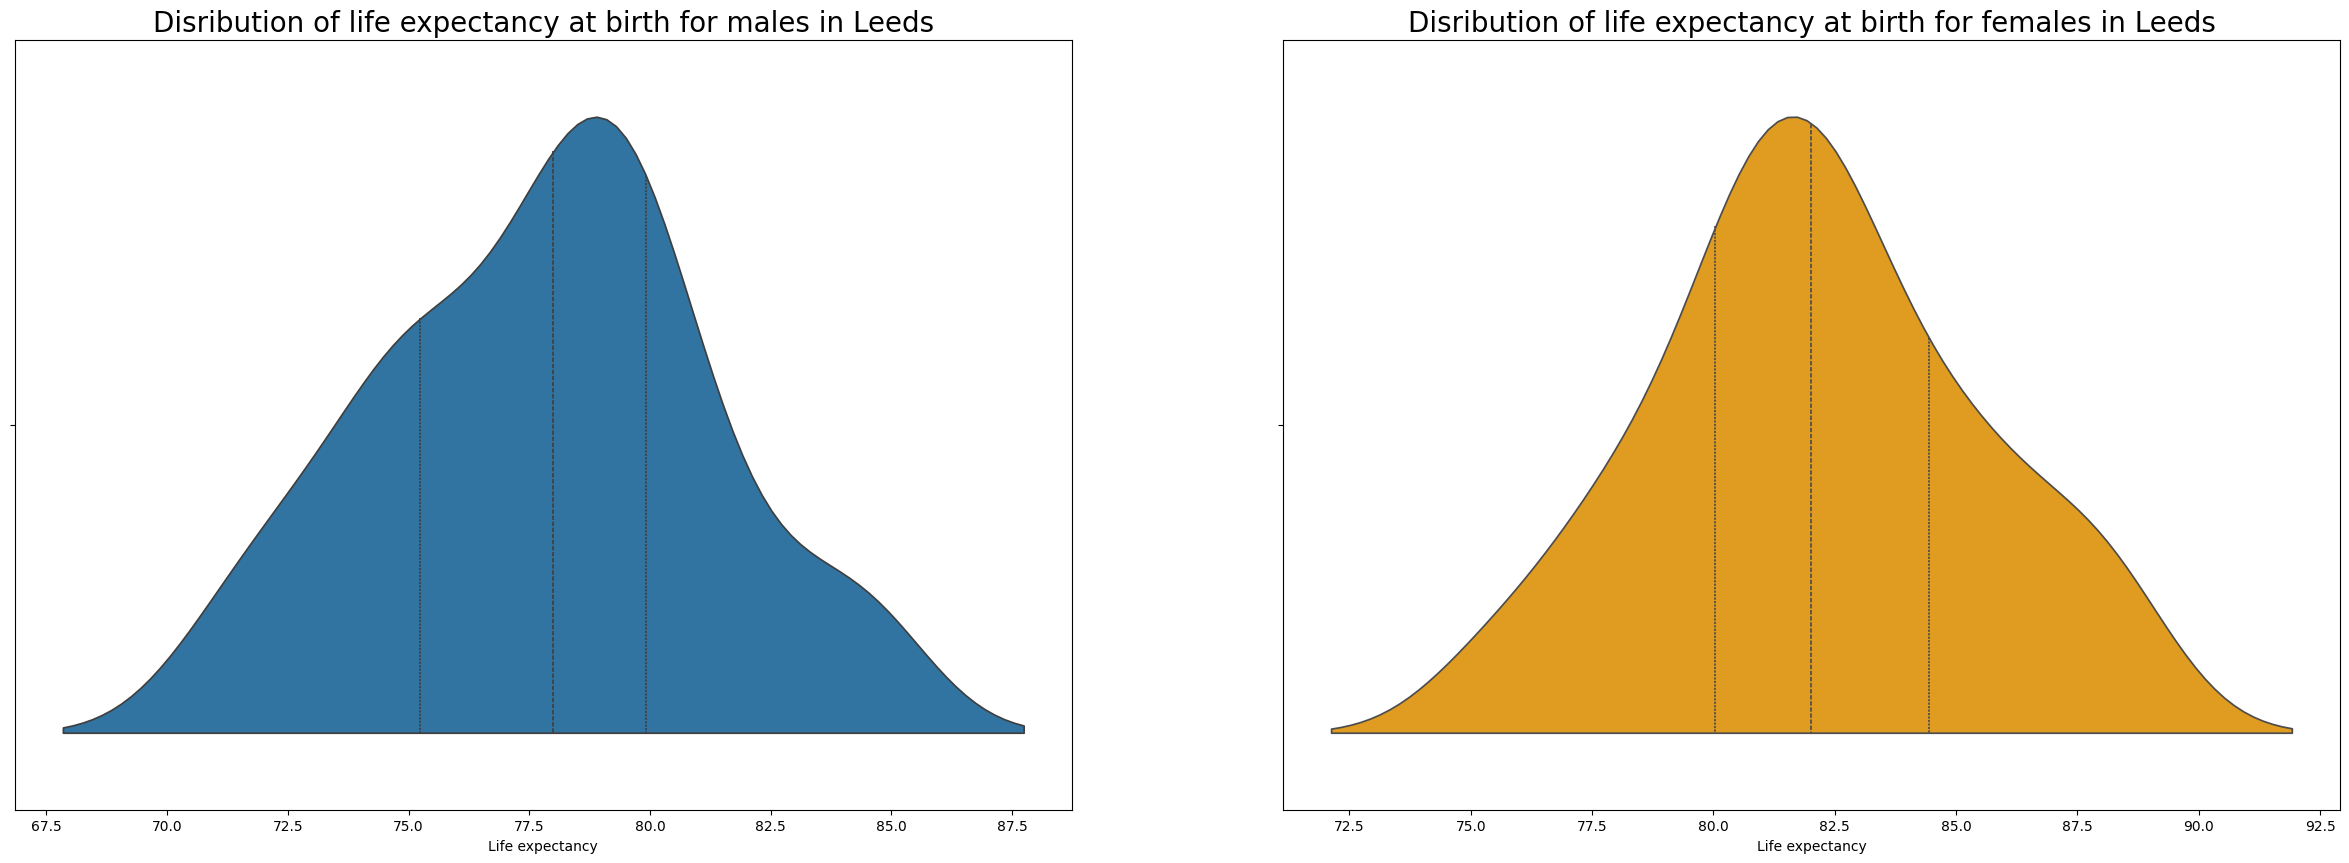

In [14]:
# create a figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(30,10))

# draw a violin plot horizontally
# add quartiles
# show an un-mirrored distribution
sns.violinplot(ax = ax[0], x=life_expectancy_males_leeds['Life expectancy'], inner='quart', split = True)
ax[0].set_title('Disribution of life expectancy at birth for males in Leeds', fontsize=20)

sns.violinplot(ax = ax[1], x=life_expectancy_females_leeds['Life expectancy'], inner='quart', split = True, color = 'orange')
ax[1].set_title('Disribution of life expectancy at birth for females in Leeds', fontsize=20)

# show figure
plt.show()

No outliers are observed.

## IMD Score Data

In [15]:
# check the first 5 rows of the data
imd.head()

,MSOAC,MSOAHOCLN,LAD19C,LAD19N,REG,LSOACOUNT,POPMID15,IMD19 SCORE,MSOARANK,MSOADECILE,MSOAQUINTILE
0,E02000001,City of London,E09000001,City of London,London,6,6687,14.720484,4198,7,4
1,E02000002,Marks Gate,E09000002,Barking and Dagenham,London,4,7379,34.767560,1060,2,1
2,E02000003,Chadwell Heath East,E09000002,Barking and Dagenham,London,6,10720,25.149726,2200,4,2
3,E02000004,Eastbrookend,E09000002,Barking and Dagenham,London,4,6536,23.560044,2429,4,2
4,E02000005,Becontree Heath,E09000002,Barking and Dagenham,London,5,9243,30.212965,1519,3,2


Below are the descriptions of columns of interest:


*   '**MSOAC**': MSOA code (2011)
*   '**IMD19 SCORE**': IMD score (2019)

Since this dataset also contains data for the whole of England, subsets for Leeds will be created in the same way as was done for the life expectancy data.

In [16]:
# extract data for Leeds
imd_leeds = imd.loc[imd['MSOAC'].isin(lookup_leeds['MSOA11CD'])]

# check the first 5 rows of the data
imd_leeds.head()

,MSOAC,MSOAHOCLN,LAD19C,LAD19N,REG,LSOACOUNT,POPMID15,IMD19 SCORE,MSOARANK,MSOADECILE,MSOAQUINTILE
2269,E02002330,Wetherby West,E08000035,Leeds,Yorkshire and The Humber,5,6518,5.014984,6634,10,5
2270,E02002331,Wetherby East & Thorp Arch,E08000035,Leeds,Yorkshire and The Humber,4,6822,17.983529,3445,6,3
2271,E02002332,Otley North,E08000035,Leeds,Yorkshire and The Humber,4,5854,16.662478,3704,6,3
2272,E02002333,Otley South,E08000035,Leeds,Yorkshire and The Humber,5,7831,11.624132,5054,8,4
2273,E02002334,Boston Spa & Bramham,E08000035,Leeds,Yorkshire and The Humber,5,7162,8.713865,5883,9,5


Let's check for missing values and data types.

In [17]:
# look at missing values and data types
# specify columns of interest
imd_leeds[['MSOAC', 'IMD19 SCORE']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 107 entries, 2269 to 6733
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MSOAC        107 non-null    object 
 1   IMD19 SCORE  107 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.5+ KB


Each column has the appropriate data type. Since each column contains 107 non-null values, there are no missing values.

Let's look at the key statistics and visualise the datasets.

In [18]:
imd_leeds['IMD19 SCORE'].describe()

,IMD19 SCORE
count,107.000000
mean,27.449366
std,17.329120
min,5.014984
25%,15.096999
50%,21.042977
75%,41.561914
max,68.385004


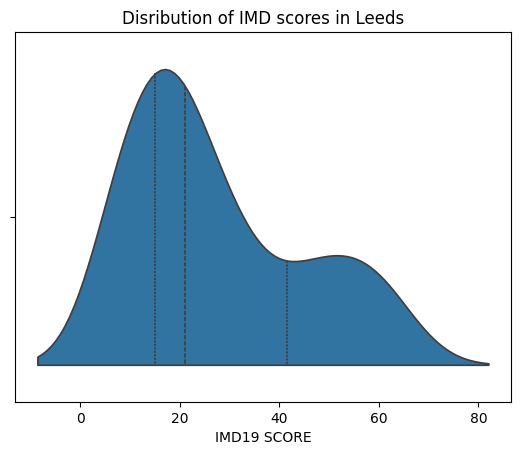

In [19]:
# creat a violinplot
fig, ax = plt.subplots()

# draw a violin plot horizontally
# add quartiles
# show an un-mirrored distribution
sns.violinplot(x=imd_leeds['IMD19 SCORE'], inner='quart', split = True)
plt.title('Disribution of IMD scores in Leeds')

plt.show()

No outliers are observed.

## MSOA Boundary Data

In [20]:
# check the first 5 rows of the data
msoa.head()

,OBJECTID,MSOA11CD,MSOA11NM,MSOA11NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry
0,1,E02000001,City of London 001,City of London 001,532378,181354,-0.093570,51.51560,7e1c3fbc-cc47-4e16-a505-d89e93921c28,"POLYGON ((-0.09676 51.52325, -0.09644 51.52282..."
1,2,E02000002,Barking and Dagenham 001,Barking and Dagenham 001,548267,189693,0.138759,51.58659,9f32701c-7edc-4f73-b8c2-a1afac813fbb,"POLYGON ((0.14811 51.59678, 0.14809 51.5964, 0..."
2,3,E02000003,Barking and Dagenham 002,Barking and Dagenham 002,548259,188522,0.138150,51.57607,7687f18e-6c8e-4afb-9c98-a9e633e00dd6,"POLYGON ((0.15065 51.58306, 0.14841 51.58075, ..."
3,4,E02000004,Barking and Dagenham 003,Barking and Dagenham 003,551004,186418,0.176830,51.55644,67259638-dce5-461c-82f7-8fbac8335b66,"POLYGON ((0.18511 51.5648, 0.18403 51.56391, 0..."
4,5,E02000005,Barking and Dagenham 004,Barking and Dagenham 004,548733,186827,0.144269,51.56071,dadad0f1-384f-4686-9535-5026812db2a9,"POLYGON ((0.14991 51.56807, 0.15078 51.56778, ..."


The dataset contains MSOAs in the whole of England and Wales. Below are the descriptions of columns of interest:

*   '**MSOA11CD**': MSOA code (2011)
*   '**geometry**': Geometric shape of MSOAs



The data for Leeds is clipped in the same manner.

In [21]:
# extract data for Leeds
msoa_leeds = msoa.loc[msoa['MSOA11CD'].isin(lookup_leeds['MSOA11CD'])]

# check the first 5 rows of the data
msoa_leeds.head()

,OBJECTID,MSOA11CD,MSOA11NM,MSOA11NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry
2269,2270,E02002330,Leeds 001,Leeds 001,439371,447998,-1.40193,53.92664,9632e070-32aa-45fe-b7b4-1d6f8d8f7b61,"POLYGON ((-1.38649 53.94319, -1.38367 53.94146..."
2270,2271,E02002331,Leeds 002,Leeds 002,442707,447641,-1.35118,53.92316,a9624f53-7bce-41ec-be69-b1dbb41cd4da,"POLYGON ((-1.34286 53.94327, -1.34394 53.93992..."
2271,2272,E02002332,Leeds 003,Leeds 003,419729,446090,-1.70116,53.91060,7e0bfcdb-69e2-4be9-90ec-e0a94d4a0ea9,"POLYGON ((-1.70708 53.91913, -1.70478 53.9182,..."
2272,2273,E02002333,Leeds 004,Leeds 004,420302,445045,-1.69251,53.90119,d2b52e8c-dbbf-4282-a9c3-98ffd9be98b5,"POLYGON ((-1.65222 53.91067, -1.65395 53.90933..."
2273,2274,E02002334,Leeds 005,Leeds 005,441960,443307,-1.36314,53.88427,bb6ca45b-6b9d-4486-8afc-d922b1b5023d,"POLYGON ((-1.35993 53.91167, -1.36065 53.91033..."


Check for missing values and data types.

In [22]:
# look at missing values and data types
# specify columns of interest
msoa_leeds[['MSOA11CD', 'geometry']].info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 107 entries, 2269 to 6733
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   MSOA11CD  107 non-null    object  
 1   geometry  107 non-null    geometry
dtypes: geometry(1), object(1)
memory usage: 2.5+ KB


Each column has the appropriate data type. Since each column contains 107 non-null values, there are no missing values.

Below is the visualization of the MSOAs in Leeds.

<Axes: >

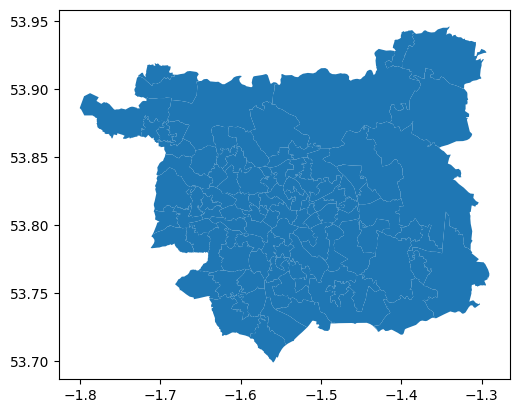

In [23]:
msoa_leeds.plot()

# Data Wrangling

A single dataframe containing only the necessary columns will be created to simplify the analysis. Since the column names in the life expectancy datasets for males and females overlap, they are renamed accordingly.

In [24]:
# merge dataframe
leeds = pd.merge(msoa_leeds, life_expectancy_males_leeds, how='left', left_on='MSOA11CD', right_on='MSOA11 Code')
# rename column name
leeds = leeds.rename(columns={'Life expectancy': 'Male life expectancy'})
# merge dataframe
leeds = pd.merge(leeds, life_expectancy_females_leeds, how='left', left_on='MSOA11CD', right_on='MSOA11 Code')
# rename column name
leeds = leeds.rename(columns={'Life expectancy': 'Female life expectancy'})
# merge dataframe
leeds = pd.merge(leeds, imd_leeds, how='left', left_on='MSOA11CD', right_on='MSOAC')

# only keep the necessary columns
leeds = leeds[['MSOA11CD',
       'Male life expectancy',
       'Female life expectancy',
       'IMD19 SCORE',
       'geometry']]

The resulting dataframe is shown below.

In [25]:
# check the first 5 rows of the data
leeds.head()

,MSOA11CD,Male life expectancy,Female life expectancy,IMD19 SCORE,geometry
0,E02002330,84.13,88.87,5.014984,"POLYGON ((-1.38649 53.94319, -1.38367 53.94146..."
1,E02002331,79.72,83.39,17.983529,"POLYGON ((-1.34286 53.94327, -1.34394 53.93992..."
2,E02002332,80.01,85.08,16.662478,"POLYGON ((-1.70708 53.91913, -1.70478 53.9182,..."
3,E02002333,80.16,83.99,11.624132,"POLYGON ((-1.65222 53.91067, -1.65395 53.90933..."
4,E02002334,79.95,88.23,8.713865,"POLYGON ((-1.35993 53.91167, -1.36065 53.91033..."


# Data Cleaning

First, the number of missing values is calculated.

In [26]:
leeds.isnull().sum()

,0
MSOA11CD,0
Male life expectancy,0
Female life expectancy,1
IMD19 SCORE,0
geometry,0


As expected, there is one missing value in the female life expectancy column. The row containing this missing value is shown below.

In [27]:
leeds.loc[leeds['Female life expectancy'].isnull()]

,MSOA11CD,Male life expectancy,Female life expectancy,IMD19 SCORE,geometry
105,E02006875,77.86,NaN,19.314787,"POLYGON ((-1.52919 53.79753, -1.53121 53.79644..."


There are various ways to handle missing values. In this case, the missing female life expectancy value could be imputed using a linear regression model fitted to the male and female life expectancy data, under the assumption that the two variables have a linear relationship. Before doing so, a scatter plot of male versus female life expectancy with a linear regression is created to visually assess whether this linear relationship holds.

In [28]:
# drop the row containing a missing value
temp = leeds.dropna(axis = 0)

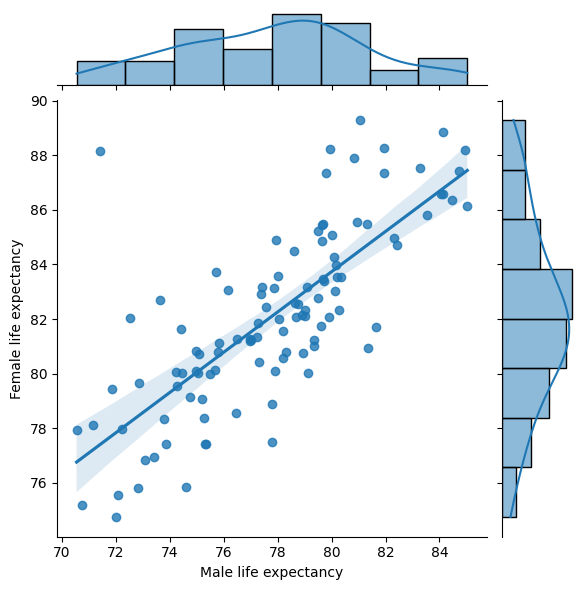

In [29]:
sns.jointplot(data = temp, x = 'Male life expectancy', y = 'Female life expectancy', kind = 'reg')

The graph above suggests a strong linear relationship. The Pearson correlation coefficient is calculated as follows to get more evidence.

In [30]:
r, p = pearsonr(temp['Male life expectancy'], temp['Female life expectancy'])
print('Pearson correlation coefficient:',r)
print('P value:',p)

Pearson correlation coefficient: 0.7662401436947075
P value: 1.0661104361199474e-21


Therefore, there is a statistically significant correlation between male and female life expectancy (p < 0.01). The Pearson correlation coefficient (r = 0.77) indicates a strong positive relationship. Therefore, it is reasonable to predict missing female life expectancy values using a linear regression model with male life expectancy as the predictor.

In [31]:
leeds.loc[leeds['Female life expectancy'].isnull(), 'Male life expectancy']

,Male life expectancy
105,77.86


Now, the missing value is predicted as shown below.

In [32]:
# set variables
y = temp['Female life expectancy']
X = temp[['Male life expectancy']]

# fit the model
reg = LinearRegression().fit(X, y)

# predict the female life expectancy
X_missing = leeds.loc[leeds['Female life expectancy'].isnull(), 'Male life expectancy']
predicted_value = reg.predict([X_missing])
print(predicted_value)

[82.15481901]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


The value is predicted as 82.1548190. Now, let's impute the missing value.

In [33]:
leeds.loc[leeds['Female life expectancy'].isnull(), 'Female life expectancy'] = predicted_value

Let's check if it has been imputed successfully.

In [34]:
leeds.isnull().sum()

,0
MSOA11CD,0
Male life expectancy,0
Female life expectancy,0
IMD19 SCORE,0
geometry,0


# *Analysis*

The association between life expectancy and IMD scores is investigated using linear regression. Linear regression is used because research has shown a linear relationship between them at the national level in England (Marmot et al., 2020). Additionally, linear regression models are easy to interpret, making it straightforward to provide insights to local authorities.

First, a linear regression model is fitted to male life expectancy and IMD scores.

In [35]:
# set variables
y1 = leeds['Male life expectancy']
X = leeds[['IMD19 SCORE']]

# fit the model
reg_males = LinearRegression().fit(X, y1)

In [36]:
# check the score
reg_males.score(X, y1)

0.6837983591099298

In [37]:
# check the coefficient
reg_males.coef_

array([-0.16452854])

In [38]:
# check the intercept
reg_males.intercept_

np.float64(82.32910120598268)

Next, a linear regression model is fitted to female life expectancy and IMD scores.

In [39]:
# set variables
y2 = leeds['Female life expectancy']
X = leeds[['IMD19 SCORE']]

# fit the model
reg_females = LinearRegression().fit(X, y2)

In [40]:
# check the score
reg_females.score(X, y2)

0.45829481161911934

In [41]:
# check the coefficient
reg_females.coef_

array([-0.12977535])

In [42]:
# check the intercept
reg_females.intercept_

np.float64(85.68229620144821)

For males, the coefficient of determination (R²) is 0.68, indicating that 68% of the variation in life expectancy is explained by IMD scores. The regression coefficient is -0.16, meaning a 1-point increase in IMD score is associated with a decrease of 0.16 years (1.9 months) in life expectancy, and the intercept of 82.3 predicts male life expectancy when IMD = 0. For females, R² is 0.46, with a coefficient of -0.13 (1.6 months decrease per IMD point) and an intercept of 85.7, suggesting women are slightly more robust against deprivation.

# Data Visualisation

## Spatial Visualisation

To help staff in Leeds City Council understand how health inequalities are distributed across Leeds, choropleth maps for male and female life expectancy are created, as shown below. A quantile scheme with five bins is used to simplify the colour differences and make the results easier to interpret. The “viridis” colour map is used because it is colour-blind friendly. A basemap is also added to help staff identify the exact locations where health inequalities exist.

The figure shows substantial spatial variation in life expectancy, highlighting a significant gap between areas. This provides insight into the severity of health inequalities in Leeds.

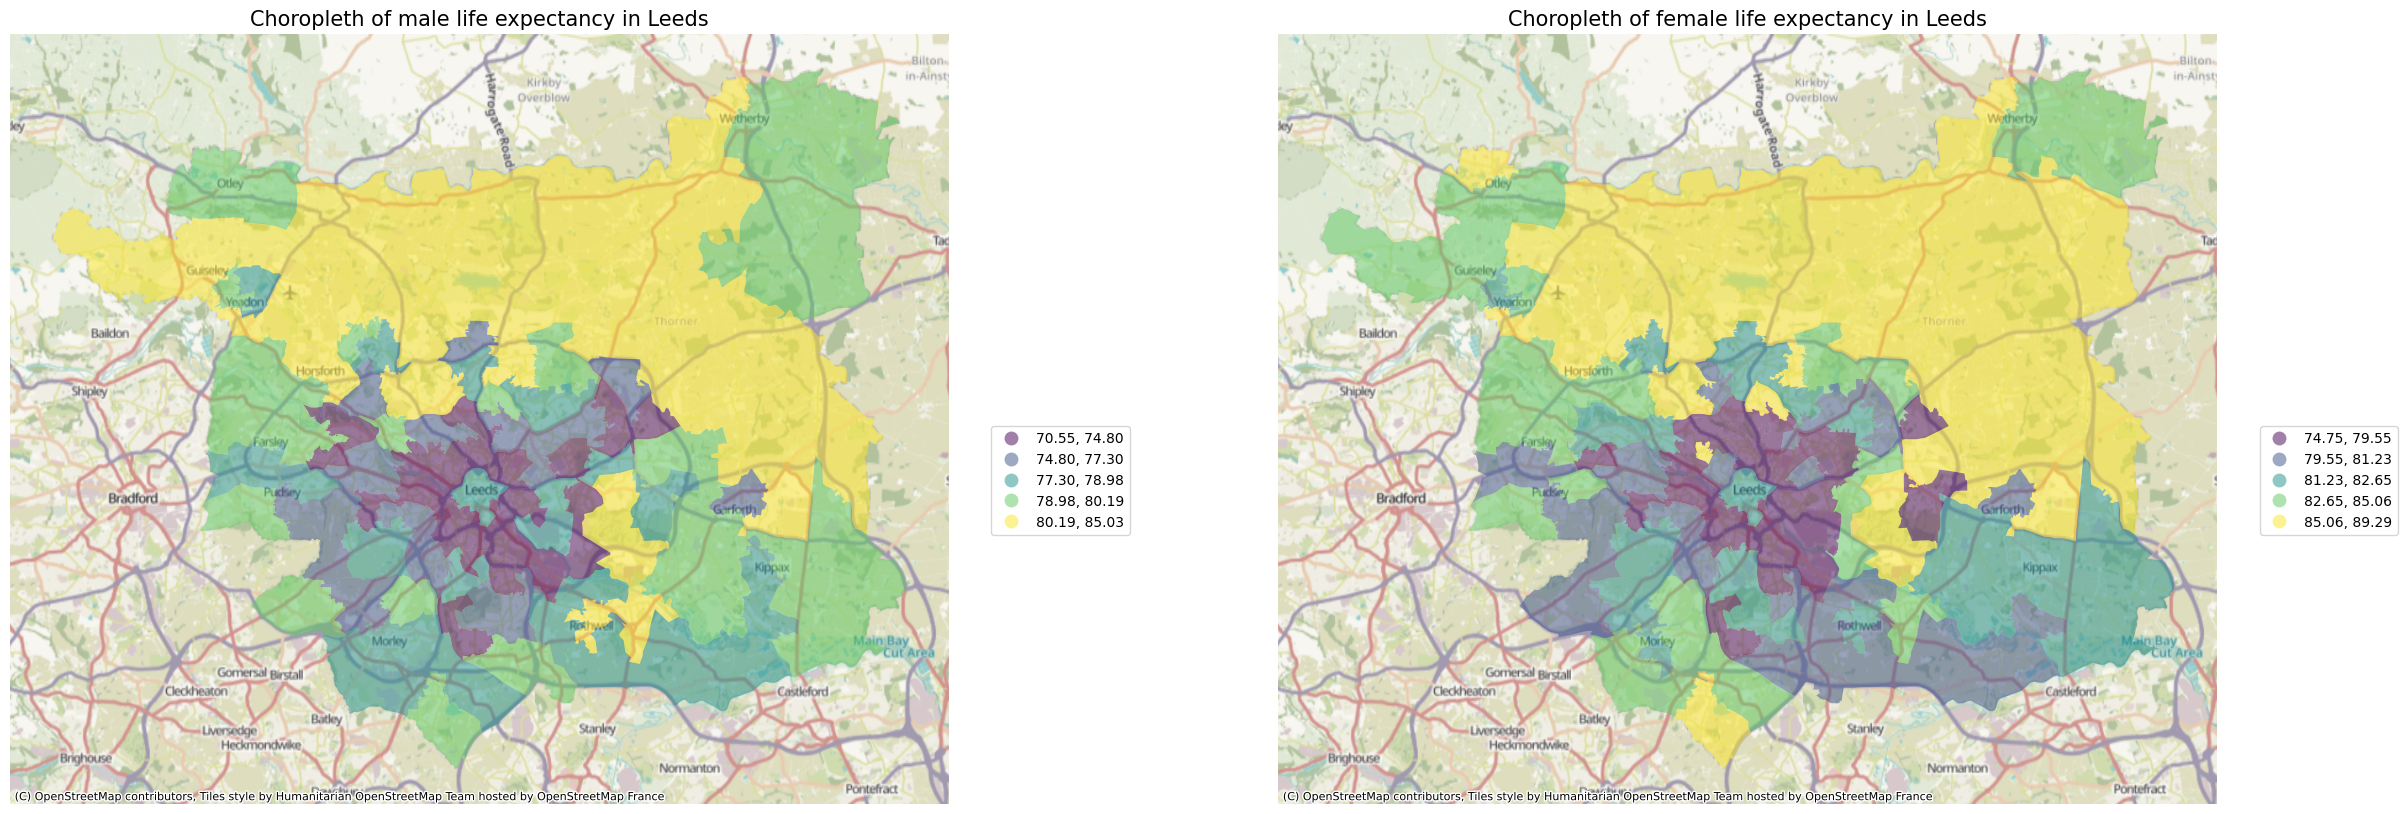

In [43]:
# create a figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(30,10))

# plot male life expectancy in subplot 1
leeds.plot(ax = ax[0], column = 'Male life expectancy', scheme = 'quantiles', k = 5, cmap = 'viridis', legend = True, alpha = 0.5)
# give an informative title
ax[0].set_title('Choropleth of male life expectancy in Leeds', fontsize=15)
# set a legend
leg1 = ax[0].get_legend()
leg1.set_bbox_to_anchor((1.2,0.5))
# create a basemap
cx.add_basemap(ax[0], crs = leeds.crs)
# make axis invisible
ax[0].set_axis_off()

# plot female life expectancy in subplot 2
leeds.plot(ax = ax[1], column = 'Female life expectancy', scheme = 'quantiles', k = 5, cmap = 'viridis', legend = True, alpha = 0.5)
# give an informative title
ax[1].set_title('Choropleth of female life expectancy in Leeds', fontsize=15)
# set legend
leg2 = ax[1].get_legend()
leg2.set_bbox_to_anchor((1.2,0.5))
# create basemap
cx.add_basemap(ax[1], crs = leeds.crs)
# make axis invisible
ax[1].set_axis_off()

# show figure
plt.show()

## Non-spatial Visualisation

To help staff in Leeds City Council understand how health inequalities are correlated with IMD scores, scatter plots with regression lines were created for male and female life expectancy. This visually illustrates the strong correlation between the variables observed in the previous analysis. The plots for both genders are displayed in the same figure to facilitate comparison. The alpha and size of the points were adjusted so that each point remains visible, even when overlapping.

It can be observed that for both male and female life expectancy, there is a negative association with IMD scores. This provides insight into how higher levels of deprivation are associated with lower life expectancy in Leeds, which can help guide local decision-making and policy planning.

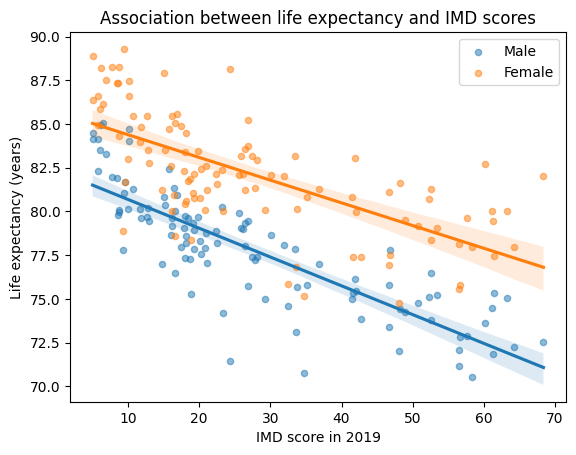

In [44]:
# create a figure
fig, ax = plt.subplots()

# plot male and female life expectancy within one figure
sns.regplot(ax = ax, data = leeds, x = 'IMD19 SCORE', y = 'Male life expectancy',label = 'Male', scatter_kws={'alpha':0.5, 's':20})
sns.regplot(ax = ax, data = leeds, x = 'IMD19 SCORE', y = 'Female life expectancy', label = 'Female', scatter_kws={'alpha':0.5, 's':20})

# give an informative title
plt.title('Association between life expectancy and IMD scores')
# set x-axis label
plt.xlabel('IMD score in 2019')
# set y-axis label
plt.ylabel('Life expectancy (years)')
# add legend
plt.legend()

# show figure
plt.show()

# References

Marmot, M., Allen, J., Boyce, T., Goldblatt, P. and Morrison, J. 2020. *The Marmot Review 10 Years On*. [Online]. London: Institute of Health Equity. [Accessed 29 January 2026]. Available at: https://www.instituteofhealthequity.org/resources-reports/marmot-review-10-years-on

Leeds Observatory. [no date]. *Guidance*. [Online]. [Accessed 30 January 2026]. Available from:https://observatory.leeds.gov.uk/guidance/

mySociety. 2019. *IMD2019 Maps*. [Online]. [Accessed 29 January 2026]. Available from: https://research.mysociety.org/sites/imd2019/about/

Office for National Statistics. 2011. *Middle layer Super Output Areas (December 2011) Boundaries EW BGC (V3)*. [Online]. [Accessed 29 January 2026]. Available from: https://geoportal.statistics.gov.uk/datasets/ons::middle-layer-super-output-areas-december-2011-boundaries-ew-bgc-v3-1/about

Office for National Statistics. 2021. *Life expectancy at birth and age 65 years by sex for Middle Layer Super Output Areas (MSOAs), England: 2016 to 2020*. [Online]. [Accessed 29 January 2026]. Available from: https://www.ons.gov.uk/peoplepopulationandcommunity/birthsdeathsandmarriages/lifeexpectancies/adhocs/13926lifeexpectancyatbirthandage65yearsbysexformiddlelayersuperoutputareasmsoasengland2016to2020

Office for National Statistics. 2025. *MSOA (2011) to MSOA (2021) to Local Authority District (2022) Best Fit Lookup for EW (V2)*. [Online]. [Accessed 29 January 2026]. Available from: https://geoportal.statistics.gov.uk/datasets/ons::msoa-2011-to-msoa-2021-to-local-authority-district-2022-best-fit-lookup-for-ew-v2/about